In [1]:
!pip install tensorflow keras matplotlib numpy seaborn efficientnet

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, applications
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import time
import pandas as pd

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.7/50.7 kB 1.8 MB/s eta 0:00:00


In [3]:
print("=== CNN ARCHITECTURE COMPARISON STUDY ===")
print("We'll compare 6 different CNN architectures on CIFAR-10 dataset")
print("This will help you understand how different designs affect performance\n")

# Set random seeds for reproducible results across all models
np.random.seed(42)
tf.random.set_seed(42)

# Load CIFAR-10 dataset - our testing ground for comparing architectures
aa_class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
                  'dog', 'frog', 'horse', 'ship', 'truck']

(aa_x_train_raw, aa_y_train_raw), (aa_x_test_raw, aa_y_test_raw) = keras.datasets.cifar10.load_data()

print("Dataset loaded successfully!")
print(f"Training images: {aa_x_train_raw.shape}")
print(f"Test images: {aa_x_test_raw.shape}")
print(f"Number of classes: {len(aa_class_names)}")

# Data preprocessing - normalize pixel values and prepare labels
aa_x_train = aa_x_train_raw.astype('float32') / 255.0
aa_x_test = aa_x_test_raw.astype('float32') / 255.0

# Convert labels to categorical format for multi-class classification
aa_y_train = keras.utils.to_categorical(aa_y_train_raw, 10)
aa_y_test = keras.utils.to_categorical(aa_y_test_raw, 10)

# Use a subset for faster training and comparison (you can increase this for better results)
aa_subset_size = 10000  # 10k training samples
aa_test_size = 2000     # 2k test samples

# FIXED: Create balanced subsets to ensure fair comparison
def create_balanced_subset(x_data, y_data, y_raw, size, num_classes=10):
    """
    Create a balanced subset maintaining equal representation from each class

    This function ensures we get exactly the same number of samples from each class,
    which makes our comparison fair across all architectures. Think of it like
    making sure we have equal representation in our test - not too many cats
    and too few airplanes!

    Parameters:
    x_data: The image data (normalized)
    y_data: The categorical labels (one-hot encoded)
    y_raw: The raw labels (single integers 0-9)
    size: Total number of samples we want
    num_classes: Number of classes (10 for CIFAR-10)
    """
    samples_per_class = size // num_classes
    indices = []

    for class_id in range(num_classes):
        # Find all indices for this class in the CORRECT dataset
        class_indices = np.where(y_raw.flatten() == class_id)[0]

        # Make sure we have enough samples of this class
        if len(class_indices) >= samples_per_class:
            selected = np.random.choice(class_indices, samples_per_class, replace=False)
            indices.extend(selected)
        else:
            # If we don't have enough, take all available samples
            indices.extend(class_indices)
            print(f"Warning: Only {len(class_indices)} samples available for class {aa_class_names[class_id]}")

    indices = np.array(indices)
    np.random.shuffle(indices)
    return x_data[indices], y_data[indices]

# Create balanced subsets using the CORRECT label arrays for each dataset
print("Creating balanced training subset...")
aa_x_train_subset, aa_y_train_subset = create_balanced_subset(
    aa_x_train, aa_y_train, aa_y_train_raw, aa_subset_size)

print("Creating balanced test subset...")
aa_x_test_subset, aa_y_test_subset = create_balanced_subset(
    aa_x_test, aa_y_test, aa_y_test_raw, aa_test_size)

print(f"\nSubset created for efficient comparison:")
print(f"Training subset: {aa_x_train_subset.shape[0]} images")
print(f"Test subset: {aa_x_test_subset.shape[0]} images")

# Let's verify our subsets are properly balanced
print(f"\nVerifying class balance in training subset:")
aa_train_class_counts = np.bincount(np.argmax(aa_y_train_subset, axis=1))
for i, count in enumerate(aa_train_class_counts):
    print(f"  {aa_class_names[i]}: {count} samples")

print(f"\nVerifying class balance in test subset:")
aa_test_class_counts = np.bincount(np.argmax(aa_y_test_subset, axis=1))
for i, count in enumerate(aa_test_class_counts):
    print(f"  {aa_class_names[i]}: {count} samples")

print(f"\n✅ Data preparation complete! Ready to build and compare CNN architectures.")

=== CNN ARCHITECTURE COMPARISON STUDY ===
We'll compare 6 different CNN architectures on CIFAR-10 dataset
This will help you understand how different designs affect performance

Dataset loaded successfully!
Training images: (50000, 32, 32, 3)
Test images: (10000, 32, 32, 3)
Number of classes: 10
Creating balanced training subset...
Creating balanced test subset...

Subset created for efficient comparison:
Training subset: 10000 images
Test subset: 2000 images

Verifying class balance in training subset:
  airplane: 1000 samples
  automobile: 1000 samples
  bird: 1000 samples
  cat: 1000 samples
  deer: 1000 samples
  dog: 1000 samples
  frog: 1000 samples
  horse: 1000 samples
  ship: 1000 samples
  truck: 1000 samples

Verifying class balance in test subset:
  airplane: 200 samples
  automobile: 200 samples
  bird: 200 samples
  cat: 200 samples
  deer: 200 samples
  dog: 200 samples
  frog: 200 samples
  horse: 200 samples
  ship: 200 samples
  truck: 200 samples

✅ Data preparation 

In [4]:
print("=== IMPLEMENTING LENET ARCHITECTURE ===")
print("LeNet is the grandfather of CNNs - simple but foundational")
print("Originally designed for handwritten digit recognition, adapted for CIFAR-10\n")

def aa_create_lenet():
    """
    Create LeNet architecture adapted for CIFAR-10

    LeNet represents the foundational CNN design from the 1990s
    It uses a simple pattern: Convolution -> Pooling -> Convolution -> Pooling -> Dense
    We'll adapt it for color images and 10 classes
    """
    aa_lenet_model = keras.Sequential([
        # Input layer for CIFAR-10 (32x32x3)
        keras.Input(shape=(32, 32, 3)),

        # First convolutional block - detects basic features
        layers.Conv2D(6, (5, 5), activation='tanh', padding='valid', name='conv1'),
        layers.AveragePooling2D((2, 2), name='pool1'),  # LeNet used average pooling originally

        # Second convolutional block - combines basic features
        layers.Conv2D(16, (5, 5), activation='tanh', padding='valid', name='conv2'),
        layers.AveragePooling2D((2, 2), name='pool2'),

        # Flatten and classify
        layers.Flatten(name='flatten'),
        layers.Dense(120, activation='tanh', name='dense1'),
        layers.Dense(84, activation='tanh', name='dense2'),
        layers.Dense(10, activation='softmax', name='output')  # 10 classes for CIFAR-10
    ], name='LeNet')

    return aa_lenet_model

# Create and compile LeNet model
aa_lenet = aa_create_lenet()
aa_lenet.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

print("LeNet Architecture:")
aa_lenet.summary()
print(f"Total parameters: {aa_lenet.count_params():,}")
print("Key characteristics: Simple design, small number of parameters, uses tanh activation")


=== IMPLEMENTING LENET ARCHITECTURE ===
LeNet is the grandfather of CNNs - simple but foundational
Originally designed for handwritten digit recognition, adapted for CIFAR-10

LeNet Architecture:


Model: "LeNet"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1 (Conv2D)                  │ (None, 28, 28, 6)      │           456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (AveragePooling2D)        │ (None, 14, 14, 6)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 10, 10, 16)     │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (AveragePooling2D)        │ (None, 5, 5, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 400)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 120)            │        48,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense2 (Dense)                  │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 62,006 (242.21 KB)

 Trainable params: 62,006 (242.21 KB)

 Non-trainable params: 0 (0.00 B)

Total parameters: 62,006
Key characteristics: Simple design, small number of parameters, uses tanh activation


In [5]:
print("=== IMPLEMENTING ALEXNET ARCHITECTURE ===")
print("AlexNet revolutionized computer vision and sparked the deep learning boom")
print("It introduced ReLU activations, dropout, and deeper architectures\n")

def aa_create_alexnet():
    """
    Create AlexNet architecture adapted for CIFAR-10

    AlexNet brought several innovations:
    - ReLU activation functions (faster than tanh)
    - Dropout for regularization
    - Deeper architecture with more parameters
    - Local Response Normalization (we'll use BatchNorm instead)
    """
    aa_alexnet_model = keras.Sequential([
        # Input layer
        keras.Input(shape=(32, 32, 3)),

        # First convolutional block - adapted for smaller CIFAR-10 images
        layers.Conv2D(64, (3, 3), activation='relu', padding='same', name='conv1'),
        layers.BatchNormalization(name='bn1'),  # Modern replacement for LRN
        layers.MaxPooling2D((2, 2), name='pool1'),

        # Second convolutional block
        layers.Conv2D(128, (3, 3), activation='relu', padding='same', name='conv2'),
        layers.BatchNormalization(name='bn2'),
        layers.MaxPooling2D((2, 2), name='pool2'),

        # Third convolutional block
        layers.Conv2D(256, (3, 3), activation='relu', padding='same', name='conv3'),
        layers.BatchNormalization(name='bn3'),

        # Fourth convolutional block
        layers.Conv2D(256, (3, 3), activation='relu', padding='same', name='conv4'),
        layers.BatchNormalization(name='bn4'),
        layers.MaxPooling2D((2, 2), name='pool3'),

        # Classification layers with dropout
        layers.Flatten(name='flatten'),
        layers.Dense(512, activation='relu', name='dense1'),
        layers.Dropout(0.5, name='dropout1'),  # Key AlexNet innovation
        layers.Dense(256, activation='relu', name='dense2'),
        layers.Dropout(0.5, name='dropout2'),
        layers.Dense(10, activation='softmax', name='output')
    ], name='AlexNet')

    return aa_alexnet_model

# Create and compile AlexNet model
aa_alexnet = aa_create_alexnet()
aa_alexnet.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

print("AlexNet Architecture:")
aa_alexnet.summary()
print(f"Total parameters: {aa_alexnet.count_params():,}")
print("Key innovations: ReLU activation, dropout regularization, deeper architecture")


=== IMPLEMENTING ALEXNET ARCHITECTURE ===
AlexNet revolutionized computer vision and sparked the deep learning boom
It introduced ReLU activations, dropout, and deeper architectures

AlexNet Architecture:


Model: "AlexNet"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1 (Conv2D)                  │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn1 (BatchNormalization)        │ (None, 32, 32, 64)     │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn2 (BatchNormalization)        │ (None, 16, 16, 128)    │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv2D)                  │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn3 (BatchNormalization)        │ (None, 8, 8, 256)      │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv4 (Conv2D)                  │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn4 (BatchNormalization)        │ (None, 8, 8, 256)      │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool3 (MaxPooling2D)            │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 512)            │     2,097,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout1 (Dropout)              │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense2 (Dense)                  │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout2 (Dropout)              │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,195,274 (12.19 MB)

 Trainable params: 3,193,866 (12.18 MB)

 Non-trainable params: 1,408 (5.50 KB)

Total parameters: 3,195,274
Key innovations: ReLU activation, dropout regularization, deeper architecture


In [6]:
print("=== IMPLEMENTING VGGNET ARCHITECTURE ===")
print("VGGNet demonstrated that depth matters - deeper networks perform better")
print("It uses very small (3x3) filters consistently throughout the network\n")

def aa_create_vggnet():
    """
    Create VGGNet architecture adapted for CIFAR-10

    VGGNet's key insights:
    - Use small (3x3) convolution filters exclusively
    - Stack multiple conv layers before pooling
    - Systematic architecture design
    - Demonstrated importance of network depth
    """
    aa_vggnet_model = keras.Sequential([
        # Input layer
        keras.Input(shape=(32, 32, 3)),

        # First VGG block - 64 filters
        layers.Conv2D(64, (3, 3), activation='relu', padding='same', name='conv1_1'),
        layers.Conv2D(64, (3, 3), activation='relu', padding='same', name='conv1_2'),
        layers.MaxPooling2D((2, 2), name='pool1'),

        # Second VGG block - 128 filters
        layers.Conv2D(128, (3, 3), activation='relu', padding='same', name='conv2_1'),
        layers.Conv2D(128, (3, 3), activation='relu', padding='same', name='conv2_2'),
        layers.MaxPooling2D((2, 2), name='pool2'),

        # Third VGG block - 256 filters
        layers.Conv2D(256, (3, 3), activation='relu', padding='same', name='conv3_1'),
        layers.Conv2D(256, (3, 3), activation='relu', padding='same', name='conv3_2'),
        layers.Conv2D(256, (3, 3), activation='relu', padding='same', name='conv3_3'),
        layers.MaxPooling2D((2, 2), name='pool3'),

        # Classification layers
        layers.Flatten(name='flatten'),
        layers.Dense(512, activation='relu', name='dense1'),
        layers.Dropout(0.5, name='dropout1'),
        layers.Dense(512, activation='relu', name='dense2'),
        layers.Dropout(0.5, name='dropout2'),
        layers.Dense(10, activation='softmax', name='output')
    ], name='VGGNet')

    return aa_vggnet_model

# Create and compile VGGNet model
aa_vggnet = aa_create_vggnet()
aa_vggnet.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

print("VGGNet Architecture:")
aa_vggnet.summary()
print(f"Total parameters: {aa_vggnet.count_params():,}")
print("Key features: Systematic design, 3x3 filters only, deeper architecture")


=== IMPLEMENTING VGGNET ARCHITECTURE ===
VGGNet demonstrated that depth matters - deeper networks perform better
It uses very small (3x3) filters consistently throughout the network

VGGNet Architecture:


Model: "VGGNet"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1_1 (Conv2D)                │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_2 (Conv2D)                │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2_1 (Conv2D)                │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2_2 (Conv2D)                │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3_1 (Conv2D)                │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3_2 (Conv2D)                │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3_3 (Conv2D)                │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool3 (MaxPooling2D)            │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 512)            │     2,097,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout1 (Dropout)              │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense2 (Dense)                  │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout2 (Dropout)              │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,100,938 (15.64 MB)

 Trainable params: 4,100,938 (15.64 MB)

 Non-trainable params: 0 (0.00 B)

Total parameters: 4,100,938
Key features: Systematic design, 3x3 filters only, deeper architecture


In [7]:
print("=== IMPLEMENTING RESNET ARCHITECTURE ===")
print("ResNet solved the vanishing gradient problem with residual connections")
print("This breakthrough enabled training of very deep networks\n")

def aa_create_resnet_block(inputs, filters, kernel_size=3, stride=1, name_prefix=""):
    """
    Create a basic ResNet residual block

    Residual blocks allow gradients to flow directly through skip connections
    This solves the vanishing gradient problem in very deep networks
    """
    # Main path
    x = layers.Conv2D(filters, kernel_size, strides=stride, padding='same',
                     name=f'{name_prefix}_conv1')(inputs)
    x = layers.BatchNormalization(name=f'{name_prefix}_bn1')(x)
    x = layers.ReLU(name=f'{name_prefix}_relu1')(x)

    x = layers.Conv2D(filters, kernel_size, padding='same',
                     name=f'{name_prefix}_conv2')(x)
    x = layers.BatchNormalization(name=f'{name_prefix}_bn2')(x)

    # Skip connection - this is the key innovation of ResNet
    if stride != 1 or inputs.shape[-1] != filters:
        # Adjust dimensions if needed
        shortcut = layers.Conv2D(filters, 1, strides=stride, padding='same',
                                name=f'{name_prefix}_shortcut')(inputs)
        shortcut = layers.BatchNormalization(name=f'{name_prefix}_shortcut_bn')(shortcut)
    else:
        shortcut = inputs

    # Add skip connection
    x = layers.Add(name=f'{name_prefix}_add')([x, shortcut])
    x = layers.ReLU(name=f'{name_prefix}_relu2')(x)

    return x

def aa_create_resnet():
    """
    Create ResNet architecture adapted for CIFAR-10

    ResNet's innovation: residual connections that allow very deep networks
    The skip connections help gradients flow back through the network
    """
    inputs = keras.Input(shape=(32, 32, 3))

    # Initial convolution
    x = layers.Conv2D(64, 7, strides=1, padding='same', name='conv1')(inputs)
    x = layers.BatchNormalization(name='bn1')(x)
    x = layers.ReLU(name='relu1')(x)

    # ResNet blocks
    x = aa_create_resnet_block(x, 64, name_prefix='block1_1')
    x = aa_create_resnet_block(x, 64, name_prefix='block1_2')

    x = aa_create_resnet_block(x, 128, stride=2, name_prefix='block2_1')
    x = aa_create_resnet_block(x, 128, name_prefix='block2_2')

    x = aa_create_resnet_block(x, 256, stride=2, name_prefix='block3_1')
    x = aa_create_resnet_block(x, 256, name_prefix='block3_2')

    # Global average pooling and classification
    x = layers.GlobalAveragePooling2D(name='global_pool')(x)
    x = layers.Dense(10, activation='softmax', name='output')(x)

    aa_resnet_model = keras.Model(inputs, x, name='ResNet')
    return aa_resnet_model

# Create and compile ResNet model
aa_resnet = aa_create_resnet()
aa_resnet.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

print("ResNet Architecture:")
aa_resnet.summary()
print(f"Total parameters: {aa_resnet.count_params():,}")
print("Key innovation: Skip connections enable training of very deep networks")


=== IMPLEMENTING RESNET ARCHITECTURE ===
ResNet solved the vanishing gradient problem with residual connections
This breakthrough enabled training of very deep networks

ResNet Architecture:


Model: "ResNet"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1 (Conv2D)      │ (None, 32, 32,    │      9,472 │ input_layer_3[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn1                 │ (None, 32, 32,    │        256 │ conv1[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ relu1 (ReLU)        │ (None, 32, 32,    │          0 │ bn1[0][0]         │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_1_conv1      │ (None, 32, 32,    │     36,928 │ relu1[0][0]       │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_1_bn1        │ (None, 32, 32,    │        256 │ block1_1_conv1[0… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_1_relu1      │ (None, 32, 32,    │          0 │ block1_1_bn1[0][… │
│ (ReLU)              │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_1_conv2      │ (None, 32, 32,    │     36,928 │ block1_1_relu1[0… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_1_bn2        │ (None, 32, 32,    │        256 │ block1_1_conv2[0… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_1_add (Add)  │ (None, 32, 32,    │          0 │ block1_1_bn2[0][… │
│                     │ 64)               │            │ relu1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_1_relu2      │ (None, 32, 32,    │          0 │ block1_1_add[0][… │
│ (ReLU)              │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_2_conv1      │ (None, 32, 32,    │     36,928 │ block1_1_relu2[0… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_2_bn1        │ (None, 32, 32,    │        256 │ block1_2_conv1[0… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_2_relu1      │ (None, 32, 32,    │          0 │ block1_2_bn1[0][… │
│ (ReLU)              │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_2_conv2      │ (None, 32, 32,    │     36,928 │ block1_2_relu1[0… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_2_bn2        │ (None, 32, 32,    │        256 │ block1_2_conv2[0… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_2_add (Add)  │ (None, 32, 32,    │          0 │ block1_2_bn2[0][

 Total params: 2,792,074 (10.65 MB)

 Trainable params: 2,787,594 (10.63 MB)

 Non-trainable params: 4,480 (17.50 KB)

Total parameters: 2,792,074
Key innovation: Skip connections enable training of very deep networks


In [8]:
print("=== IMPLEMENTING MOBILENET AND EFFICIENTNET ===")
print("These are modern efficient architectures designed for mobile devices")
print("MobileNet uses depthwise separable convolutions for efficiency\n")

def aa_create_mobilenet():
    """
    Create MobileNet architecture for CIFAR-10

    MobileNet innovations:
    - Depthwise separable convolutions (much more efficient)
    - Designed for mobile and embedded devices
    - Good accuracy with fewer parameters
    """
    aa_mobilenet_model = keras.Sequential([
        keras.Input(shape=(32, 32, 3)),

        # Standard convolution
        layers.Conv2D(32, (3, 3), strides=1, padding='same', activation='relu', name='conv1'),
        layers.BatchNormalization(name='bn1'),

        # Depthwise separable convolutions - MobileNet's key innovation
        layers.DepthwiseConv2D((3, 3), padding='same', activation='relu', name='dw_conv1'),
        layers.BatchNormalization(name='dw_bn1'),
        layers.Conv2D(64, (1, 1), activation='relu', name='pw_conv1'),
        layers.BatchNormalization(name='pw_bn1'),

        layers.DepthwiseConv2D((3, 3), strides=2, padding='same', activation='relu', name='dw_conv2'),
        layers.BatchNormalization(name='dw_bn2'),
        layers.Conv2D(128, (1, 1), activation='relu', name='pw_conv2'),
        layers.BatchNormalization(name='pw_bn2'),

        layers.DepthwiseConv2D((3, 3), padding='same', activation='relu', name='dw_conv3'),
        layers.BatchNormalization(name='dw_bn3'),
        layers.Conv2D(128, (1, 1), activation='relu', name='pw_conv3'),
        layers.BatchNormalization(name='pw_bn3'),

        layers.DepthwiseConv2D((3, 3), strides=2, padding='same', activation='relu', name='dw_conv4'),
        layers.BatchNormalization(name='dw_bn4'),
        layers.Conv2D(256, (1, 1), activation='relu', name='pw_conv4'),
        layers.BatchNormalization(name='pw_bn4'),

        # Global average pooling and classification
        layers.GlobalAveragePooling2D(name='global_pool'),
        layers.Dense(10, activation='softmax', name='output')
    ], name='MobileNet')

    return aa_mobilenet_model

# Create MobileNet using Keras implementation adapted for CIFAR-10
aa_mobilenet_base = applications.MobileNetV2(
    input_shape=(32, 32, 3),
    alpha=1.0,
    include_top=False,
    weights=None  # Train from scratch for fair comparison
)

aa_mobilenet = keras.Sequential([
    aa_mobilenet_base,
    layers.GlobalAveragePooling2D(),
    layers.Dense(10, activation='softmax')
], name='MobileNet')

# Create EfficientNet using Keras implementation
try:
    from tensorflow.keras.applications import EfficientNetB0
    aa_efficientnet_base = EfficientNetB0(
        input_shape=(32, 32, 3),
        include_top=False,
        weights=None  # Train from scratch for fair comparison
    )

    aa_efficientnet = keras.Sequential([
        aa_efficientnet_base,
        layers.GlobalAveragePooling2D(),
        layers.Dense(10, activation='softmax')
    ], name='EfficientNet')

except ImportError:
    # If EfficientNet is not available, create a simplified version
    print("Creating simplified EfficientNet...")
    aa_efficientnet = keras.Sequential([
        keras.Input(shape=(32, 32, 3)),
        layers.Conv2D(32, 3, activation='swish', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(64, 3, strides=2, activation='swish', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(128, 3, strides=2, activation='swish', padding='same'),
        layers.BatchNormalization(),
        layers.GlobalAveragePooling2D(),
        layers.Dense(10, activation='softmax')
    ], name='EfficientNet')

# Compile both models
aa_mobilenet.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
aa_efficientnet.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

print("MobileNet Architecture:")
print(f"Total parameters: {aa_mobilenet.count_params():,}")
print("Key feature: Depthwise separable convolutions for efficiency")

print("\nEfficientNet Architecture:")
print(f"Total parameters: {aa_efficientnet.count_params():,}")
print("Key feature: Compound scaling of depth, width, and resolution")


=== IMPLEMENTING MOBILENET AND EFFICIENTNET ===
These are modern efficient architectures designed for mobile devices
MobileNet uses depthwise separable convolutions for efficiency

MobileNet Architecture:
Total parameters: 2,270,794
Key feature: Depthwise separable convolutions for efficiency

EfficientNet Architecture:
Total parameters: 4,062,381
Key feature: Compound scaling of depth, width, and resolution


In [9]:
print("=== TRAINING ALL CNN ARCHITECTURES ===")
print("Now we'll train all 6 architectures and compare their performance")
print("This will show us how different designs affect learning speed and accuracy\n")

# Store all models in a dictionary for easy iteration
aa_models = {
    'LeNet': aa_lenet,
    'AlexNet': aa_alexnet,
    'VGGNet': aa_vggnet,
    'ResNet': aa_resnet,
    'MobileNet': aa_mobilenet,
    'EfficientNet': aa_efficientnet
}

# Training configuration
aa_epochs = 10  # Reduced for faster comparison
aa_batch_size = 32
aa_validation_split = 0.2

# Storage for results
aa_training_histories = {}
aa_training_times = {}
aa_model_parameters = {}

print("Training configuration:")
print(f"Epochs: {aa_epochs}")
print(f"Batch size: {aa_batch_size}")
print(f"Validation split: {aa_validation_split}")
print(f"Training samples per model: {len(aa_x_train_subset) * (1 - aa_validation_split):.0f}")

# Set up early stopping to prevent overfitting
aa_early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=0
)

# Train each model and record results
for model_name, model in aa_models.items():
    print(f"\n{'='*50}")
    print(f"Training {model_name}...")
    print(f"{'='*50}")

    # Record model parameters
    aa_model_parameters[model_name] = model.count_params()

    # Train the model and measure time
    start_time = time.time()

    history = model.fit(
        aa_x_train_subset, aa_y_train_subset,
        batch_size=aa_batch_size,
        epochs=aa_epochs,
        validation_split=aa_validation_split,
        callbacks=[aa_early_stopping],
        verbose=1
    )

    end_time = time.time()
    training_time = end_time - start_time

    # Store results
    aa_training_histories[model_name] = history
    aa_training_times[model_name] = training_time

    # Print summary statistics
    final_acc = history.history['accuracy'][-1]
    final_val_acc = history.history['val_accuracy'][-1]

    print(f"\n{model_name} Training Summary:")
    print(f"Training time: {training_time:.1f} seconds")
    print(f"Final training accuracy: {final_acc:.4f}")
    print(f"Final validation accuracy: {final_val_acc:.4f}")
    print(f"Parameters: {aa_model_parameters[model_name]:,}")

print(f"\n{'='*50}")
print("All models trained successfully!")
print(f"{'='*50}")


=== TRAINING ALL CNN ARCHITECTURES ===
Now we'll train all 6 architectures and compare their performance
This will show us how different designs affect learning speed and accuracy

Training configuration:
Epochs: 10
Batch size: 32
Validation split: 0.2
Training samples per model: 8000

Training LeNet...
Epoch 1/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.2403 - loss: 2.0925 - val_accuracy: 0.3400 - val_loss: 1.8444
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.3431 - loss: 1.8319 - val_accuracy: 0.3540 - val_loss: 1.7933
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accuracy: 0.3725 - loss: 1.7668 - val_accuracy: 0.3615 - val_loss: 1.7660
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.3923 - loss: 1.7215 - val_accuracy: 0.3610 - val_loss: 1.7424
Epoch 5/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.4025 - loss: 1.6731 - val_accuracy: 0.3705 - val_loss: 1.7154
Epoch 6/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/st

In [10]:
print("=== EVALUATING ALL MODELS ON TEST DATA ===")
print("Let's see how each architecture performs on completely unseen data")
print("This tells us which designs generalize best to new images\n")

# Evaluate all models on test data
aa_test_results = {}

for model_name, model in aa_models.items():
    print(f"Evaluating {model_name}...")

    # Evaluate on test set
    test_loss, test_accuracy = model.evaluate(aa_x_test_subset, aa_y_test_subset, verbose=0)

    # Get predictions for detailed analysis
    predictions = model.predict(aa_x_test_subset, verbose=0)
    predicted_classes = np.argmax(predictions, axis=1)
    true_classes = np.argmax(aa_y_test_subset, axis=1)

    # Store results
    aa_test_results[model_name] = {
        'test_accuracy': test_accuracy,
        'test_loss': test_loss,
        'predictions': predictions,
        'predicted_classes': predicted_classes,
        'training_time': aa_training_times[model_name],
        'parameters': aa_model_parameters[model_name]
    }

    print(f"{model_name}: Test Accuracy = {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")

# Create comprehensive comparison DataFrame
aa_comparison_data = []
for model_name in aa_models.keys():
    results = aa_test_results[model_name]
    history = aa_training_histories[model_name]

    aa_comparison_data.append({
        'Model': model_name,
        'Test Accuracy': results['test_accuracy'],
        'Test Loss': results['test_loss'],
        'Training Time (s)': results['training_time'],
        'Parameters': results['parameters'],
        'Final Train Acc': history.history['accuracy'][-1],
        'Final Val Acc': history.history['val_accuracy'][-1],
        'Epochs Trained': len(history.history['accuracy'])
    })

aa_comparison_df = pd.DataFrame(aa_comparison_data)

print(f"\n=== COMPREHENSIVE MODEL COMPARISON ===")
print(aa_comparison_df.round(4))

# Identify best performers
best_accuracy = aa_comparison_df.loc[aa_comparison_df['Test Accuracy'].idxmax()]
fastest_training = aa_comparison_df.loc[aa_comparison_df['Training Time (s)'].idxmin()]
most_efficient = aa_comparison_df.loc[aa_comparison_df['Parameters'].idxmin()]

print(f"\n=== PERFORMANCE HIGHLIGHTS ===")
print(f"🏆 Highest Accuracy: {best_accuracy['Model']} ({best_accuracy['Test Accuracy']:.4f})")
print(f"⚡ Fastest Training: {fastest_training['Model']} ({fastest_training['Training Time (s)']:.1f}s)")
print(f"📱 Most Efficient: {most_efficient['Model']} ({most_efficient['Parameters']:,} parameters)")

# Calculate efficiency metrics
aa_comparison_df['Accuracy per Parameter'] = aa_comparison_df['Test Accuracy'] / (aa_comparison_df['Parameters'] / 1000000)
aa_comparison_df['Accuracy per Second'] = aa_comparison_df['Test Accuracy'] / aa_comparison_df['Training Time (s)']

most_param_efficient = aa_comparison_df.loc[aa_comparison_df['Accuracy per Parameter'].idxmax()]
most_time_efficient = aa_comparison_df.loc[aa_comparison_df['Accuracy per Second'].idxmax()]

print(f"💡 Best Accuracy/Parameter: {most_param_efficient['Model']}")
print(f"🚀 Best Accuracy/Time: {most_time_efficient['Model']}")


=== EVALUATING ALL MODELS ON TEST DATA ===
Let's see how each architecture performs on completely unseen data
This tells us which designs generalize best to new images

Evaluating LeNet...
LeNet: Test Accuracy = 0.4475 (44.75%)
Evaluating AlexNet...
AlexNet: Test Accuracy = 0.5620 (56.20%)
Evaluating VGGNet...
VGGNet: Test Accuracy = 0.1000 (10.00%)
Evaluating ResNet...
ResNet: Test Accuracy = 0.5270 (52.70%)
Evaluating MobileNet...
MobileNet: Test Accuracy = 0.1000 (10.00%)
Evaluating EfficientNet...
EfficientNet: Test Accuracy = 0.3270 (32.70%)

=== COMPREHENSIVE MODEL COMPARISON ===
          Model  Test Accuracy  Test Loss  Training Time (s)  Parameters  \
0         LeNet         0.4475     1.5668            44.2100       62006   
1       AlexNet         0.5620     1.2747           869.9302     3195274   
2        VGGNet         0.1000     2.3029          1124.5179     4100938   
3        ResNet         0.5270     1.3579          3121.9577     2792074   
4     MobileNet         0.1

=== CREATING COMPREHENSIVE VISUALIZATIONS ===
These charts will help us understand the trade-offs between different architectures



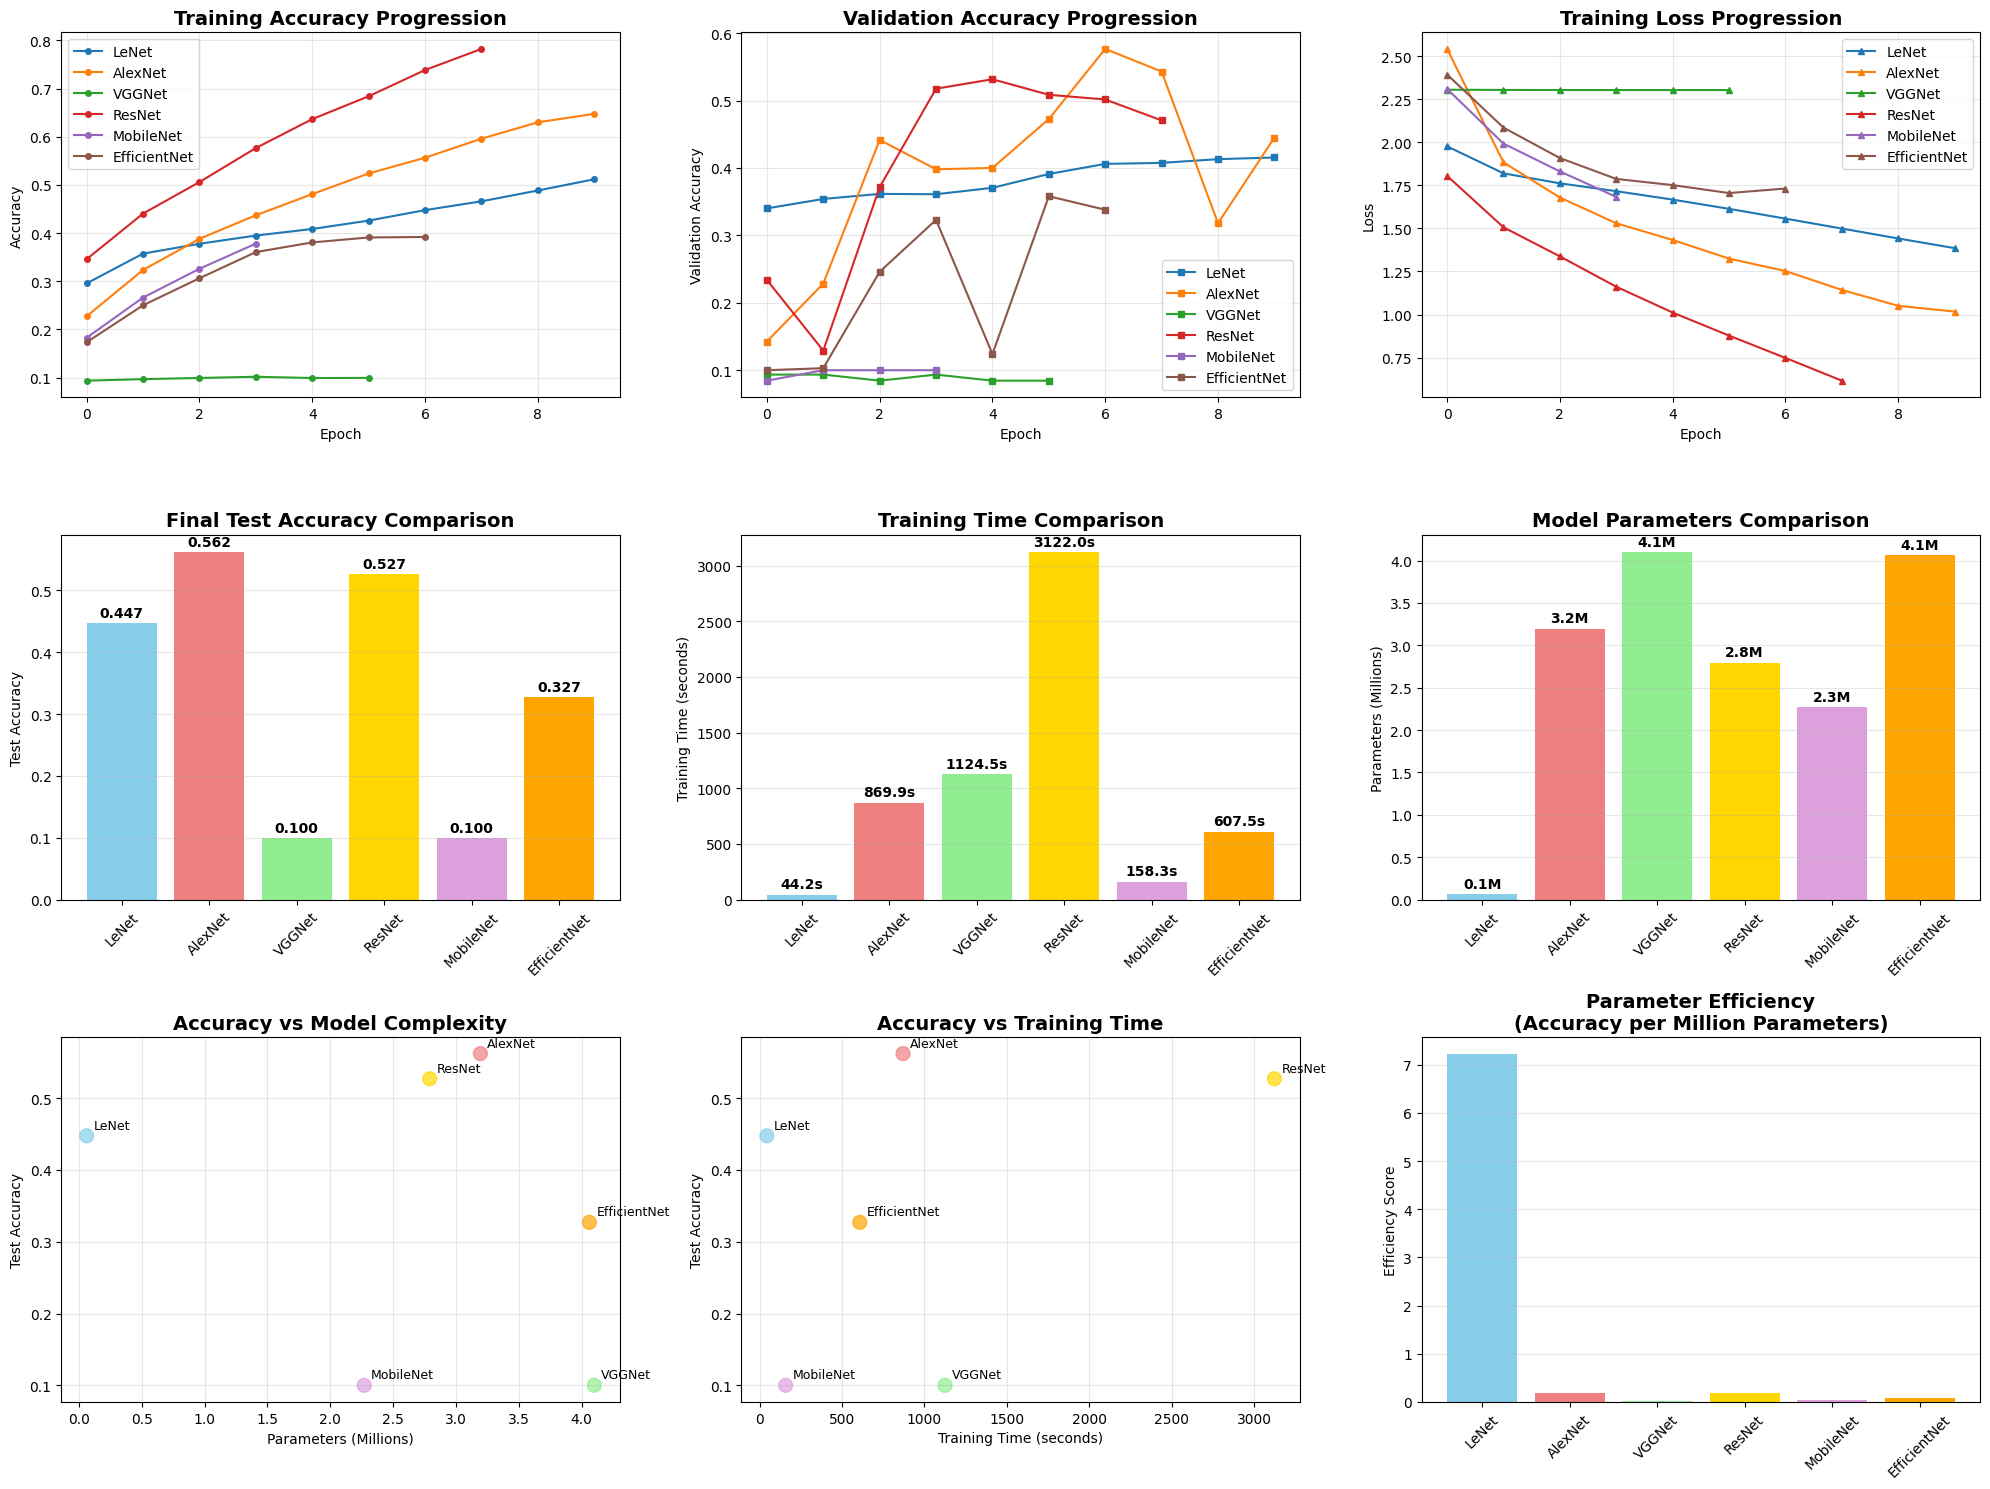

=== DETAILED ARCHITECTURE ANALYSIS ===

Key insights from our comprehensive comparison:

1. ACCURACY PERFORMANCE:
   1. AlexNet: 0.5620 (56.20%)
   2. ResNet: 0.5270 (52.70%)
   3. LeNet: 0.4475 (44.75%)
   4. EfficientNet: 0.3270 (32.70%)
   5. VGGNet: 0.1000 (10.00%)
   6. MobileNet: 0.1000 (10.00%)

2. TRAINING EFFICIENCY:
   1. LeNet: 44.2 seconds
   2. MobileNet: 158.3 seconds
   3. EfficientNet: 607.5 seconds
   4. AlexNet: 869.9 seconds
   5. VGGNet: 1124.5 seconds
   6. ResNet: 3122.0 seconds

3. PARAMETER EFFICIENCY:
   1. LeNet: 62,006 parameters
   2. MobileNet: 2,270,794 parameters
   3. ResNet: 2,792,074 parameters
   4. AlexNet: 3,195,274 parameters
   5. EfficientNet: 4,062,381 parameters
   6. VGGNet: 4,100,938 parameters


In [11]:
print("=== CREATING COMPREHENSIVE VISUALIZATIONS ===")
print("These charts will help us understand the trade-offs between different architectures\n")

# Create a comprehensive visualization dashboard
fig = plt.figure(figsize=(20, 15))

# 1. Training accuracy comparison
plt.subplot(3, 3, 1)
for model_name, history in aa_training_histories.items():
    plt.plot(history.history['accuracy'], label=model_name, marker='o', markersize=4)
plt.title('Training Accuracy Progression', fontsize=14, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

# 2. Validation accuracy comparison
plt.subplot(3, 3, 2)
for model_name, history in aa_training_histories.items():
    plt.plot(history.history['val_accuracy'], label=model_name, marker='s', markersize=4)
plt.title('Validation Accuracy Progression', fontsize=14, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

# 3. Training loss comparison
plt.subplot(3, 3, 3)
for model_name, history in aa_training_histories.items():
    plt.plot(history.history['loss'], label=model_name, marker='^', markersize=4)
plt.title('Training Loss Progression', fontsize=14, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

# 4. Final test accuracy comparison
plt.subplot(3, 3, 4)
models = list(aa_test_results.keys())
accuracies = [aa_test_results[model]['test_accuracy'] for model in models]
bars = plt.bar(models, accuracies, color=['skyblue', 'lightcoral', 'lightgreen', 'gold', 'plum', 'orange'])
plt.title('Final Test Accuracy Comparison', fontsize=14, fontweight='bold')
plt.ylabel('Test Accuracy')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{acc:.3f}', ha='center', va='bottom', fontweight='bold')

# 5. Training time comparison
plt.subplot(3, 3, 5)
times = [aa_training_times[model] for model in models]
bars = plt.bar(models, times, color=['skyblue', 'lightcoral', 'lightgreen', 'gold', 'plum', 'orange'])
plt.title('Training Time Comparison', fontsize=14, fontweight='bold')
plt.ylabel('Training Time (seconds)')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)

# Add value labels
for bar, time_val in zip(bars, times):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(times)*0.01,
             f'{time_val:.1f}s', ha='center', va='bottom', fontweight='bold')

# 6. Model parameters comparison
plt.subplot(3, 3, 6)
params = [aa_model_parameters[model]/1000000 for model in models]  # Convert to millions
bars = plt.bar(models, params, color=['skyblue', 'lightcoral', 'lightgreen', 'gold', 'plum', 'orange'])
plt.title('Model Parameters Comparison', fontsize=14, fontweight='bold')
plt.ylabel('Parameters (Millions)')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)

# Add value labels
for bar, param in zip(bars, params):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(params)*0.01,
             f'{param:.1f}M', ha='center', va='bottom', fontweight='bold')

# 7. Accuracy vs Parameters scatter plot
plt.subplot(3, 3, 7)
accuracies = [aa_test_results[model]['test_accuracy'] for model in models]
params = [aa_model_parameters[model]/1000000 for model in models]
colors = ['skyblue', 'lightcoral', 'lightgreen', 'gold', 'plum', 'orange']

scatter = plt.scatter(params, accuracies, c=colors, s=100, alpha=0.7)
for i, model in enumerate(models):
    plt.annotate(model, (params[i], accuracies[i]),
                xytext=(5, 5), textcoords='offset points', fontsize=9)

plt.title('Accuracy vs Model Complexity', fontsize=14, fontweight='bold')
plt.xlabel('Parameters (Millions)')
plt.ylabel('Test Accuracy')
plt.grid(True, alpha=0.3)

# 8. Accuracy vs Training Time scatter plot
plt.subplot(3, 3, 8)
times = [aa_training_times[model] for model in models]
scatter = plt.scatter(times, accuracies, c=colors, s=100, alpha=0.7)
for i, model in enumerate(models):
    plt.annotate(model, (times[i], accuracies[i]),
                xytext=(5, 5), textcoords='offset points', fontsize=9)

plt.title('Accuracy vs Training Time', fontsize=14, fontweight='bold')
plt.xlabel('Training Time (seconds)')
plt.ylabel('Test Accuracy')
plt.grid(True, alpha=0.3)

# 9. Efficiency metrics comparison
plt.subplot(3, 3, 9)
efficiency_acc_per_param = [acc/param for acc, param in zip(accuracies, params)]
bars = plt.bar(models, efficiency_acc_per_param, color=['skyblue', 'lightcoral', 'lightgreen', 'gold', 'plum', 'orange'])
plt.title('Parameter Efficiency\n(Accuracy per Million Parameters)', fontsize=14, fontweight='bold')
plt.ylabel('Efficiency Score')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Print detailed analysis of the results
print("=== DETAILED ARCHITECTURE ANALYSIS ===")
print("\nKey insights from our comprehensive comparison:")

print(f"\n1. ACCURACY PERFORMANCE:")
sorted_by_accuracy = sorted(aa_comparison_df.iterrows(), key=lambda x: x[1]['Test Accuracy'], reverse=True)
for i, (_, row) in enumerate(sorted_by_accuracy):
    print(f"   {i+1}. {row['Model']}: {row['Test Accuracy']:.4f} ({row['Test Accuracy']*100:.2f}%)")

print(f"\n2. TRAINING EFFICIENCY:")
sorted_by_time = sorted(aa_comparison_df.iterrows(), key=lambda x: x[1]['Training Time (s)'])
for i, (_, row) in enumerate(sorted_by_time):
    print(f"   {i+1}. {row['Model']}: {row['Training Time (s)']:.1f} seconds")

print(f"\n3. PARAMETER EFFICIENCY:")
sorted_by_params = sorted(aa_comparison_df.iterrows(), key=lambda x: x[1]['Parameters'])
for i, (_, row) in enumerate(sorted_by_params):
    print(f"   {i+1}. {row['Model']}: {row['Parameters']:,} parameters")


=== PER-CLASS PERFORMANCE ANALYSIS ===
Let's see which models perform best for each type of object
This helps us understand the strengths and weaknesses of each architecture



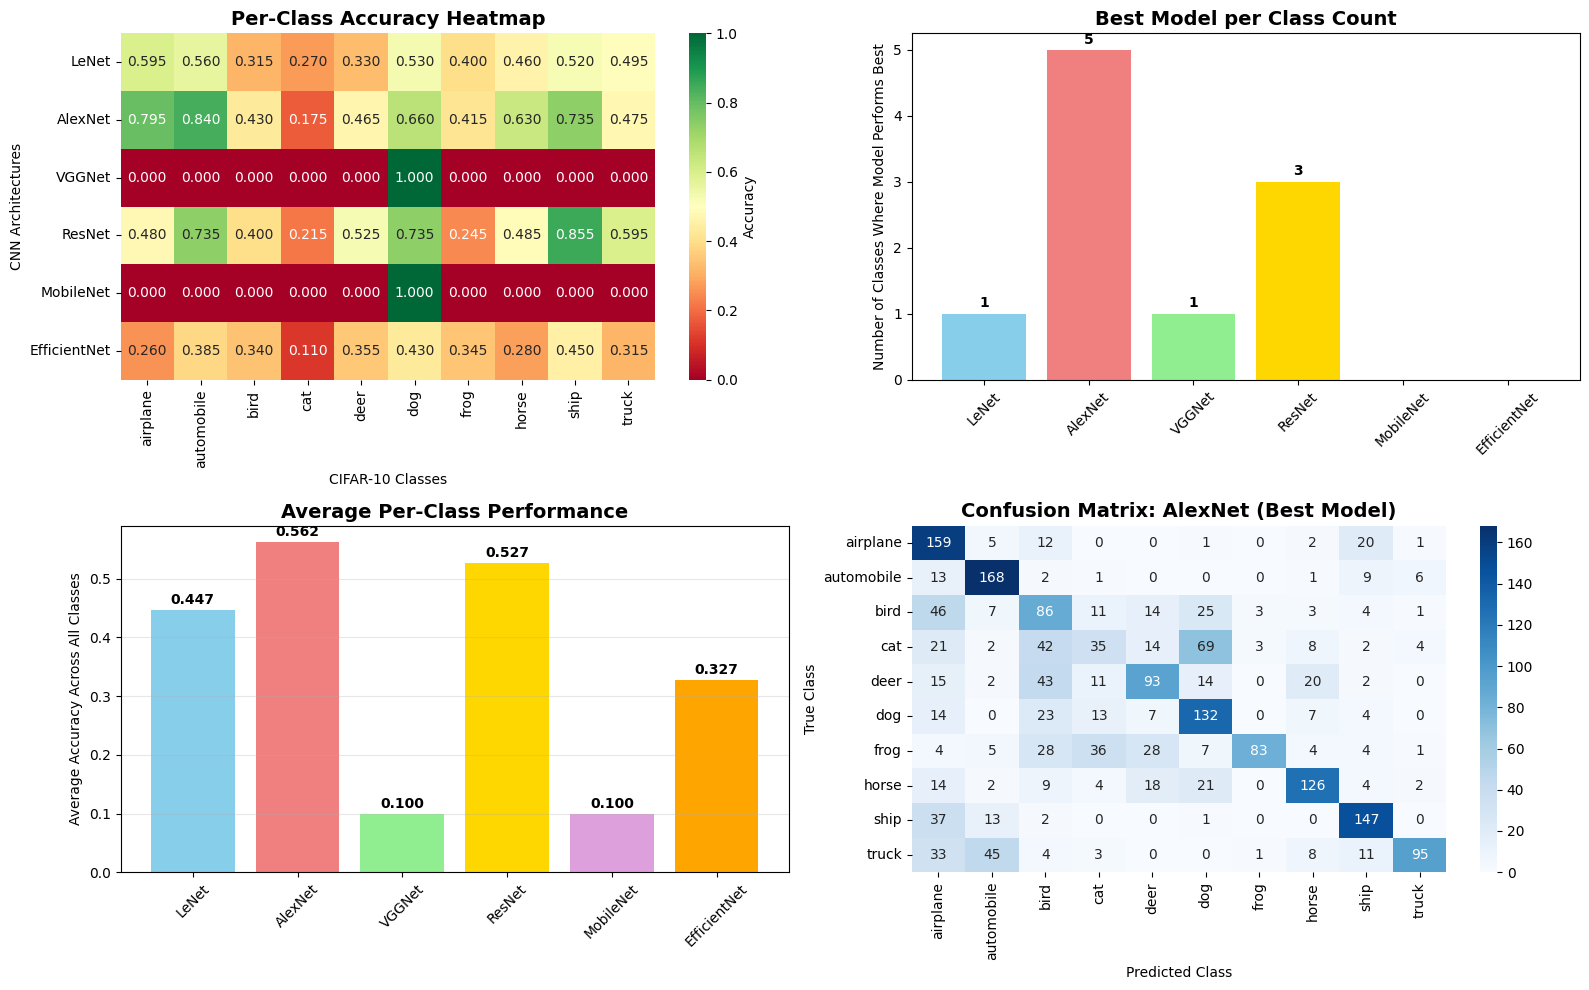

=== CLASS-SPECIFIC INSIGHTS ===

AIRPLANE:
  Best: AlexNet (0.795)
  Worst: MobileNet (0.000)

AUTOMOBILE:
  Best: AlexNet (0.840)
  Worst: MobileNet (0.000)

BIRD:
  Best: AlexNet (0.430)
  Worst: MobileNet (0.000)

CAT:
  Best: LeNet (0.270)
  Worst: MobileNet (0.000)

DEER:
  Best: ResNet (0.525)
  Worst: MobileNet (0.000)

DOG:
  Best: VGGNet (1.000)
  Worst: EfficientNet (0.430)

FROG:
  Best: AlexNet (0.415)
  Worst: MobileNet (0.000)

HORSE:
  Best: AlexNet (0.630)
  Worst: MobileNet (0.000)

SHIP:
  Best: ResNet (0.855)
  Worst: MobileNet (0.000)

TRUCK:
  Best: ResNet (0.595)
  Worst: MobileNet (0.000)

FINAL RECOMMENDATIONS FOR DIFFERENT SCENARIOS

🎯 FOR MAXIMUM ACCURACY:
   Choose: AlexNet
   Accuracy: 0.5620 (56.20%)
   Trade-offs: 3,195,274 parameters, 869.9s training time

⚡ FOR FAST TRAINING:
   Choose: LeNet
   Training time: 44.2 seconds
   Accuracy: 0.4475 (44.75%)


In [12]:
print("=== PER-CLASS PERFORMANCE ANALYSIS ===")
print("Let's see which models perform best for each type of object")
print("This helps us understand the strengths and weaknesses of each architecture\n")

# Analyze per-class performance for each model
aa_per_class_results = {}

for model_name in aa_models.keys():
    predicted_classes = aa_test_results[model_name]['predicted_classes']
    true_classes = np.argmax(aa_y_test_subset, axis=1)

    # Calculate accuracy for each class
    class_accuracies = []
    for class_id in range(10):
        class_mask = (true_classes == class_id)
        if np.sum(class_mask) > 0:  # Make sure we have samples of this class
            class_predictions = predicted_classes[class_mask]
            class_accuracy = np.mean(class_predictions == class_id)
            class_accuracies.append(class_accuracy)
        else:
            class_accuracies.append(0.0)

    aa_per_class_results[model_name] = class_accuracies

# Create per-class performance visualization
plt.figure(figsize=(16, 10))

# Heatmap of per-class accuracies
plt.subplot(2, 2, 1)
heatmap_data = np.array([aa_per_class_results[model] for model in aa_models.keys()])
sns.heatmap(heatmap_data,
            xticklabels=aa_class_names,
            yticklabels=list(aa_models.keys()),
            annot=True, fmt='.3f', cmap='RdYlGn',
            cbar_kws={'label': 'Accuracy'})
plt.title('Per-Class Accuracy Heatmap', fontsize=14, fontweight='bold')
plt.xlabel('CIFAR-10 Classes')
plt.ylabel('CNN Architectures')

# Best model for each class
plt.subplot(2, 2, 2)
best_models_per_class = []
for class_id in range(10):
    class_scores = [aa_per_class_results[model][class_id] for model in aa_models.keys()]
    best_model_idx = np.argmax(class_scores)
    best_models_per_class.append(list(aa_models.keys())[best_model_idx])

class_counts = {model: best_models_per_class.count(model) for model in aa_models.keys()}
bars = plt.bar(class_counts.keys(), class_counts.values(),
               color=['skyblue', 'lightcoral', 'lightgreen', 'gold', 'plum', 'orange'])
plt.title('Best Model per Class Count', fontsize=14, fontweight='bold')
plt.ylabel('Number of Classes Where Model Performs Best')
plt.xticks(rotation=45)

for bar, count in zip(bars, class_counts.values()):
    if count > 0:
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                 str(count), ha='center', va='bottom', fontweight='bold')

# Average performance across all classes
plt.subplot(2, 2, 3)
avg_per_class = [np.mean(aa_per_class_results[model]) for model in aa_models.keys()]
bars = plt.bar(aa_models.keys(), avg_per_class,
               color=['skyblue', 'lightcoral', 'lightgreen', 'gold', 'plum', 'orange'])
plt.title('Average Per-Class Performance', fontsize=14, fontweight='bold')
plt.ylabel('Average Accuracy Across All Classes')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)

for bar, avg in zip(bars, avg_per_class):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{avg:.3f}', ha='center', va='bottom', fontweight='bold')

# Confusion matrix for the best performing model
plt.subplot(2, 2, 4)
best_model_name = aa_comparison_df.loc[aa_comparison_df['Test Accuracy'].idxmax(), 'Model']
best_predicted = aa_test_results[best_model_name]['predicted_classes']
true_classes = np.argmax(aa_y_test_subset, axis=1)
cm = confusion_matrix(true_classes, best_predicted)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=aa_class_names, yticklabels=aa_class_names)
plt.title(f'Confusion Matrix: {best_model_name} (Best Model)', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Class')
plt.ylabel('True Class')

plt.tight_layout()
plt.show()

# Print detailed class analysis
print(f"=== CLASS-SPECIFIC INSIGHTS ===")
for class_id, class_name in enumerate(aa_class_names):
    class_scores = [(model, aa_per_class_results[model][class_id]) for model in aa_models.keys()]
    class_scores.sort(key=lambda x: x[1], reverse=True)

    print(f"\n{class_name.upper()}:")
    print(f"  Best: {class_scores[0][0]} ({class_scores[0][1]:.3f})")
    print(f"  Worst: {class_scores[-1][0]} ({class_scores[-1][1]:.3f})")

# Final recommendations based on different use cases
print(f"\n{'='*60}")
print("FINAL RECOMMENDATIONS FOR DIFFERENT SCENARIOS")
print(f"{'='*60}")

print(f"\n🎯 FOR MAXIMUM ACCURACY:")
best_acc_model = aa_comparison_df.loc[aa_comparison_df['Test Accuracy'].idxmax()]
print(f"   Choose: {best_acc_model['Model']}")
print(f"   Accuracy: {best_acc_model['Test Accuracy']:.4f} ({best_acc_model['Test Accuracy']*100:.2f}%)")
print(f"   Trade-offs: {best_acc_model['Parameters']:,} parameters, {best_acc_model['Training Time (s)']:.1f}s training time")

print(f"\n⚡ FOR FAST TRAINING:")
fastest_model = aa_comparison_df.loc[aa_comparison_df['Training Time (s)'].idxmin()]
print(f"   Choose: {fastest_model['Model']}")
print(f"   Training time: {fastest_model['Training Time (s)']:.1f} seconds")
print(f"   Accuracy: {fastest_model['Test Accuracy']:.4f} ({fastest_model['Test Accuracy']*100:.2f}%)")
